# Tensors and Forward Propagation

## Keep every reading with the example it belongs to

Imagine receiving sensor readings from three greenhouses at once. Each greenhouse reports two values: soil dryness and air warmth. We want a small network to produce one score for each greenhouse.

With one example, we could write the arithmetic on paper. With several examples, we also need to organize the numbers carefully. A dryness value must meet the weight intended for dryness, and a final score must still belong to the right greenhouse.

This is where **tensors** help. A tensor is an array of numbers arranged along axes. The arrangement lets us apply the same calculations to many examples without losing their relationships.

**Forward propagation**, also called a forward pass, is the sequence of calculations that carries those inputs through a model to its outputs. We will follow both the numbers and their arrangement along that path.

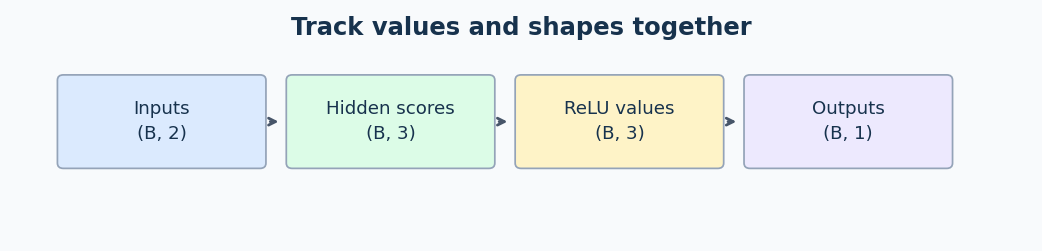

The [code companion](05_Tensors_and_Forward_Propagation.ipynb) reproduces the whole calculation in PyTorch. The readings and parameters are hand-chosen for learning; the resulting scores are not validated watering advice.

## Start with the problem this lesson solves

A network must process many examples efficiently while keeping each feature paired with the right weight. A tensor is a multidimensional array with named roles for its axes in our design. Forward propagation is the sequence of calculations that turns the input tensor into predictions using the current parameters.

The practical problem is not only calculating a number; it is calculating the intended number. Two arrays can have compatible shapes yet represent the wrong feature pairings or bias direction.

## Expand a batched forward pass into ordinary arithmetic

Rows of the input are greenhouses and columns are dryness and warmth:

$$X=\begin{bmatrix}0.8&0.4\\0.2&0.9\\0.5&0.5\end{bmatrix},\quad
W=\begin{bmatrix}1&1\\1&-1\\-1&1\end{bmatrix},\quad b=[0,-0.5,0.25].$$

$X$ has shape $(3,2)$ and $W$ has shape $(3,2)$ because each of three neurons has two weights. We use $Z=XW^T+b$: $(3,2)\times(2,3)$ produces a $(3,3)$ table. Each result is one greenhouse–neuron pairing.

| Greenhouse | Neuron one | Neuron two | Neuron three |
| --- | --- | --- | --- |
| A | $0.8+0.4+0=1.2$ | $0.8-0.4-0.5=-0.1$ | $-0.8+0.4+0.25=-0.15$ |
| B | $0.2+0.9+0=1.1$ | $0.2-0.9-0.5=-1.2$ | $-0.2+0.9+0.25=0.95$ |
| C | $0.5+0.5+0=1.0$ | $0.5-0.5-0.5=-0.5$ | $-0.5+0.5+0.25=0.25$ |

ReLU replaces every negative entry with zero:

$$H=\begin{bmatrix}1.2&0&0\\1.1&0&0.95\\1&0&0.25\end{bmatrix}.$$

The output uses weight row $[2,-1,0.5]$ and bias $-0.5$:

- A: $1.2(2)+0(-1)+0(0.5)-0.5=1.9$.
- B: $1.1(2)+0(-1)+0.95(0.5)-0.5=2.175$.
- C: $1(2)+0(-1)+0.25(0.5)-0.5=1.625$.

The final tensor has shape $(3,1)$: one score per greenhouse. These scores are not automatically probabilities or watering quantities; a task and output interpretation must define their meaning.

**Why bias direction matters.** Each neuron must use its own bias on every row. Before bias, A's three sums are $[1.2,0.4,-0.4]$. Adding $[0,-0.5,0.25]$ across that row gives the correct $[1.2,-0.1,-0.15]$. If we instead add a column vector, A receives zero on all three entries, B receives $-0.5$ on all entries, and C receives $0.25$ on all entries. The shape still happens to be $(3,3)$, but the model is different.

## Why tensors help the ANN do its job

Matrix multiplication performs the same multiply-and-add operation for many neurons and examples at once. It makes the computation efficient without changing its logic. Transpose aligns features with their corresponding weights; broadcasting reuses each bias on the intended axis.

A forward pass changes intermediate values, not stored parameters. To learn, we still need targets, a loss, gradients, and an optimizer. In this MLP, examples do not mix during prediction; layers such as training-mode batch normalization can behave differently, so this independence should not be assumed for every architecture.

## Start with a number, then a row, then a table

One dryness reading, such as $0.8$, is a single number. In tensor language, this is a **scalar**. Put dryness and warmth together as $(0.8,0.4)$ and we have a **vector**: one sequence of values.

Place several such rows together and we have a **matrix**, a rectangular table. These are different arrangements within the same broader idea of tensors.

A **shape** lists how many entries lie along each axis. An axis is one direction in which we can select entries, such as choosing a row or choosing a column.

| Arrangement | Shape | How to read it |
| --- | --- | --- |
| One scalar | `()` | No axes, but one value |
| One sensor pair | `(2,)` | One axis holding two values |
| A one-row table | `(1, 2)` | One example, two features |
| A three-row table | `(3, 2)` | Three examples, two features per example |

The empty parentheses for a scalar do not mean there are no values. An empty vector would instead have shape `(0,)`. The comma in `(2,)` is Python notation for a shape containing just one axis length.

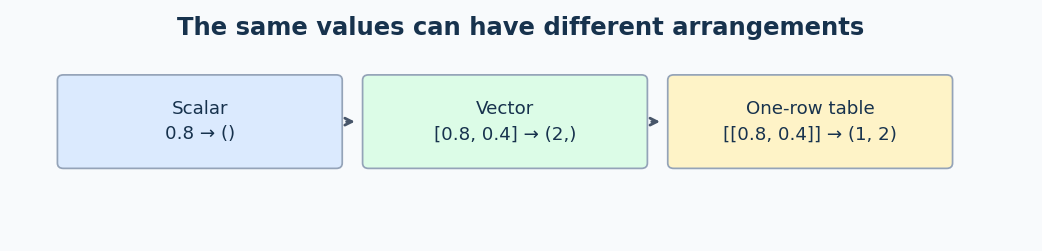

The number of axes is the tensor’s dimensionality, sometimes called rank in array terminology. More axes are useful for more structured data: an image batch can have axes for examples, color channels, height, and width. Our sensor example only needs a table.

## Decide what each row and column means

Here is our input data:

| Greenhouse | Dryness | Warmth |
| --- | --- | --- |
| A | 0.8 | 0.4 |
| B | 0.2 | 0.9 |
| C | 0.5 | 0.5 |

Each sensor uses a fixed scale from zero to one. Larger readings mean drier soil and warmer air. These are normalized teaching readings, not temperatures in degrees.

The tensor contains only the numerical entries:

$$X=\begin{bmatrix}0.8&0.4\\0.2&0.9\\0.5&0.5\end{bmatrix}.$$

The letter $X$ names the input table. We choose rows for examples and columns for features. Its shape is `(3, 2)`. More generally, we write `(B, d)`, where $B$ is the number of examples in a **batch** and $d$ is the number of features.

The computer does not know that the first column means dryness. If we accidentally reverse the columns, the shape stays valid but the model receives a different problem. Names and axis meanings therefore matter alongside sizes.

## Keep the numerical type and location compatible

A tensor needs more than a shape. It also has a **dtype**, describing how numbers are stored, and a **device**, describing where the computation happens.

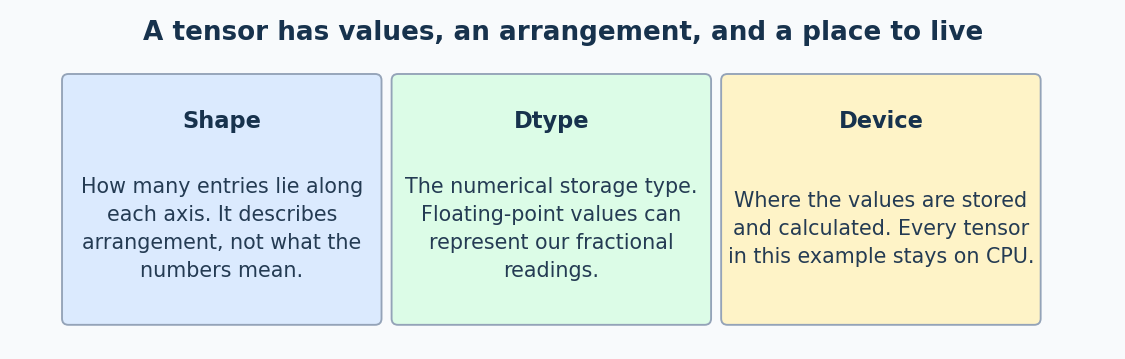

We use `float32`, a floating-point format that can represent fractional values such as $0.8$. It uses finite precision, so a stored value may differ slightly from the exact decimal. This is why the code compares calculations with a small rounding tolerance.

Integer storage would not retain these fractional readings correctly. The model parameters and input tensors also need compatible numerical types and devices. Our example keeps everything on CPU, so no transfer between a CPU and a GPU is needed.

These choices do not teach the network anything. They make sure the numerical operations can represent and process the intended values.

## Select one greenhouse without losing track of its shape

PyTorch indexing starts at zero. `X[0]` therefore selects greenhouse A’s row. It returns the vector `(0.8,0.4)` with shape `(2,)` because selecting a single row this way removes the row axis.

A slice, `X[0:1]`, selects the same row while preserving it as a one-row table. Its shape is `(1, 2)`.

| Expression | Selected values | Resulting shape |
| --- | --- | --- |
| `X` | All greenhouses | `(3, 2)` |
| `X[0]` | A’s two readings | `(2,)` |
| `X[0:1]` | A’s readings as one table row | `(1, 2)` |

Neither selection is automatically wrong. They describe the same values with different arrangements. Keeping a batch axis is useful when the rest of our code expects every input to have rows for examples and columns for features.

## Separate individual contributions from their sum

Suppose one unit compares dryness and warmth using weights $(1,-1)$. For greenhouse A, multiply the matching entries:

| Feature | Input | Weight | Contribution |
| --- | --- | --- | --- |
| Dryness | 0.8 | 1 | 0.8 |
| Warmth | 0.4 | -1 | -0.4 |

The two contributions are $(0.8,-0.4)$. Adding them gives $0.4$. The first result is a pair of values; the second is one combined score.

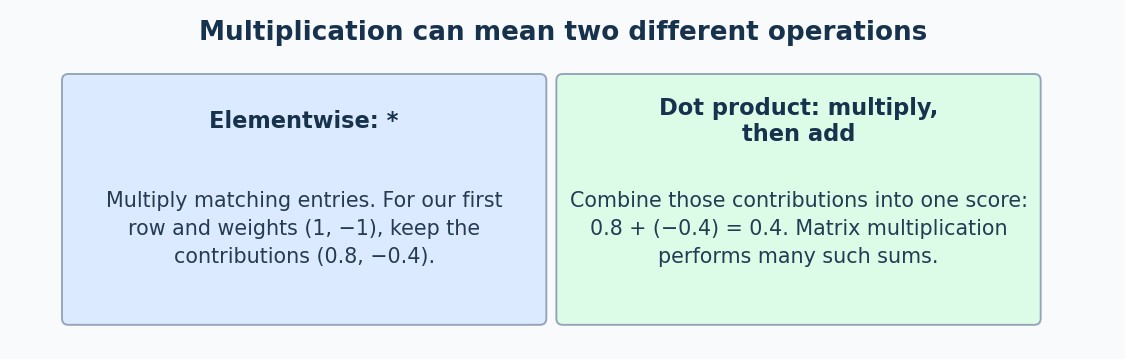

In PyTorch, `*` performs **elementwise multiplication**, multiplying corresponding entries with broadcasting where allowed. A **dot product** multiplies matching entries and adds the results.

For the matrices used here, `@` performs matrix multiplication: it computes a dot product between each row on the left and each column on the right. That lets us calculate many examples and many output units together.

## Arrange the weights so the matching features meet

Our hidden layer has three units. Each receives the two sensor readings, so each needs two weights. PyTorch stores one unit’s weights per row:

$$W=\begin{bmatrix}1&1\\1&-1\\-1&1\end{bmatrix}.$$

The first row adds the readings. The second subtracts warmth from dryness. The third subtracts dryness from warmth. Each unit also receives its own bias, stored as $b=(0,-0.5,0.25)$.

$W$ has shape `(3, 2)`: three output units, two input weights each. To multiply input rows by the correct weight columns, transpose this matrix. A **transpose** exchanges rows and columns, giving $W^T$ shape `(2, 3)`.

The hidden scores are

$$Z=XW^T+b.$$

$Z$ names the output score table. The superscript $T$ means transpose; it is not a power.

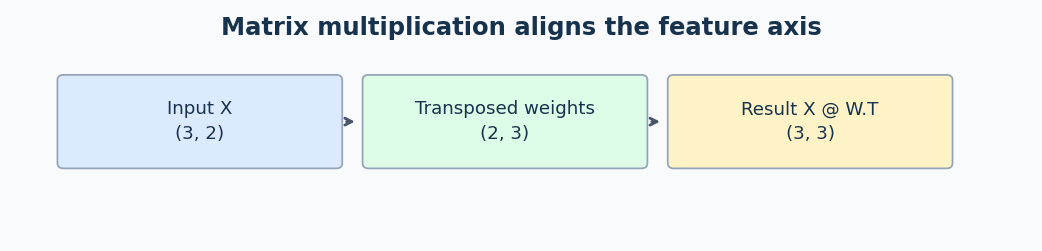

The general shape rule is `(B, d) @ (d, h) → (B, h)`. The common size $d$ counts the features being multiplied and summed. $h$ is the number of output units. The inner sizes must agree for this matrix multiplication.

## Follow the first row, then the whole batch

For greenhouse A, calculate one score per unit and add that unit’s bias:

| Unit | Weighted sum plus bias | Score |
| --- | --- | --- |
| First | $0.8+0.4+0$ | 1.2 |
| Second | $0.8-0.4-0.5$ | -0.1 |
| Third | $-0.8+0.4+0.25$ | -0.15 |

Repeating the same computation for B and C gives

$$Z=\begin{bmatrix}1.2&-0.1&-0.15\\1.1&-1.2&0.95\\1.0&-0.5&0.25\end{bmatrix}.$$

Now apply **ReLU** to each entry: keep positive values, replace negative ones by zero. Call the resulting hidden-value table $H$:

$$H=\begin{bmatrix}1.2&0&0\\1.1&0&0.95\\1.0&0&0.25\end{bmatrix}.$$

The shape remains `(3, 3)`. The first axis still identifies the same greenhouses. The second axis now identifies hidden units, not the original sensor features. Activations changed the values without adding or removing examples.

## Add a shared bias along the intended axis

The score table has several rows, but the bias vector only contains one offset per unit. **Broadcasting** lets the vector be reused across all example rows without explicitly writing a separate copy for each one.

PyTorch compares shapes from the right. Aligned axis lengths must be equal or one must be one. A missing leading axis behaves like a length-one axis.

| Bias shape | What gets repeated | Matches our layer? |
| --- | --- | --- |
| `(3,)` | One bias per unit, shared across rows | Yes |
| `(1, 3)` | The same bias row for every example | Yes |
| `(3, 1)` | One offset per example, shared across units | No |

Our score table happens to be square: the batch size and hidden width are both three. That means the incorrect column-shaped bias also runs. It silently changes the calculation.

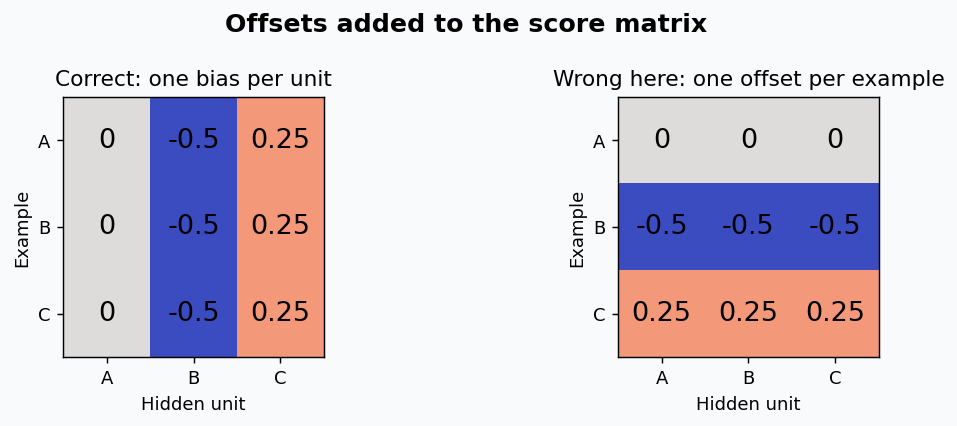

Each colored panel shows the offsets added to the scores. On the left, every example receives the same set of per-unit biases. On the right, different examples receive different offsets across all their units. The shapes are compatible in both cases, but only the first has the intended meaning.

## Complete the trip to the output

The output layer receives the hidden rows. Give it weights $(2,-1,0.5)$ and bias $c=-0.5$. Stored as a one-row matrix, these weights are $V$ with shape `(1, 3)`.

The output scores are $S=HV^T+c$:

| Greenhouse | Hidden values | Output calculation | Score |
| --- | --- | --- | --- |
| A | $(1.2,0,0)$ | $2(1.2)-0+0.5(0)-0.5$ | 1.9 |
| B | $(1.1,0,0.95)$ | $2(1.1)-0+0.5(0.95)-0.5$ | 2.175 |
| C | $(1,0,0.25)$ | $2(1)-0+0.5(0.25)-0.5$ | 1.625 |

The result is a column shaped `(3, 1)`. Each greenhouse has one output, and the row order is preserved.

That is a complete forward pass: input table, hidden scores, activated hidden values, and output scores. It uses the parameters currently stored in the model. It does not improve or learn them merely by performing the calculations.

These outputs have no validated watering meaning. Their purpose is to make every step inspectable.

## A batch shares parameters, not the identities of its examples

For this model, each row travels independently through the same dense layers and ReLU. Calculating all rows together gives the same answers, up to floating-point rounding, as processing each row separately and joining the outputs.

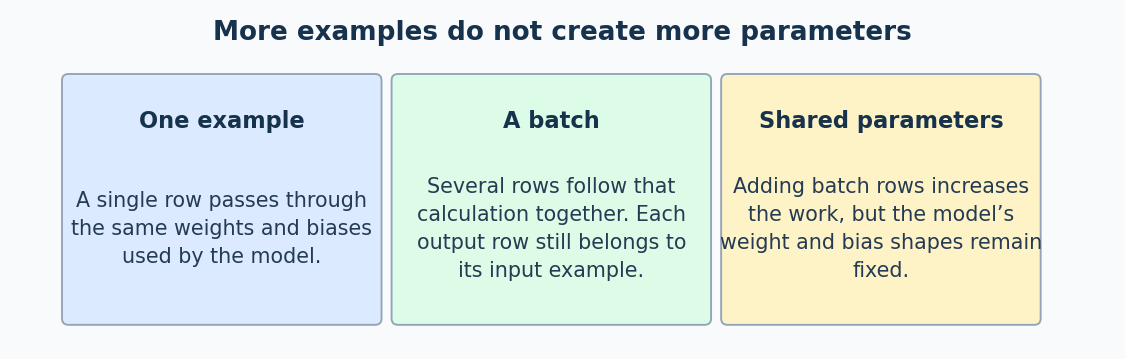

Reordering the input rows should reorder the output rows in the same way. Changing greenhouse A should not change B or C’s output. The companion verifies these properties to catch accidental mixing of the example axis.

This independence follows from our particular operations. A model that uses statistics across a batch can behave differently; we should not assume every network processes rows independently.

**Vectorization** means expressing many calculations as array operations instead of writing a separate Python loop for every example. It lets numerical libraries handle the work efficiently without adding new model parameters.

## Reshaping is not the same as swapping axes

Consider a small table with rows `(1, 2, 3)` and `(4, 5, 6)`. It contains six values arranged as two rows of three.

A transpose exchanges the row and column axes. The first column becomes the first row, producing `(1, 4)`, `(2, 5)`, and `(3, 6)`.

A **reshape** into three rows of two instead groups the original values in their existing traversal order: `(1, 2)`, `(3, 4)`, and `(5, 6)`.

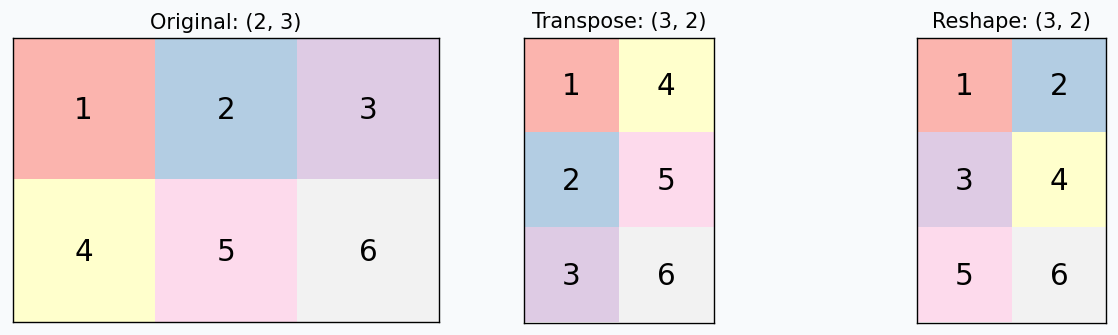

| Operation | What it preserves | What it changes |
| --- | --- | --- |
| Transpose | Each value’s relationship to the exchanged axes | Which axis is read as rows or columns |
| Reshape | Total number of values and traversal order | How values are grouped into a new shape |

A reshape does not know which measurements belong to the same greenhouse. It is not a substitute for transposing the weight matrix. Flattening the entire batch can likewise mix the example axis with the feature axis.

Reshaping can reuse existing storage or make a copy when needed. A new shape alone is not a promise of independent data; an explicit copy is needed when independence is the goal.

## Connect the arithmetic to a PyTorch model

`nn.Linear(d, h)` implements the weighted sums and bias additions, with $d$ input features and $h$ outputs. ReLU is a separate module. Chaining the appropriate modules reproduces the tensor calculations above.

The companion copies our chosen weights into such a model and compares its outputs with the manual matrix calculation. Both routes produce the same scores because the connections and parameter values match.

| Instruction | Role |
| --- | --- |
| `nn.Linear(...)` | Combine inputs with stored weights and bias |
| `nn.ReLU()` | Replace negative scores by zero |
| `model.eval()` | Select evaluation behavior for layers that distinguish it |
| `torch.no_grad()` | Avoid recording operations for gradient computation |

The dense/ReLU model has no train-versus-evaluation behavior change. Neither evaluation mode nor disabling gradient recording trains the model.

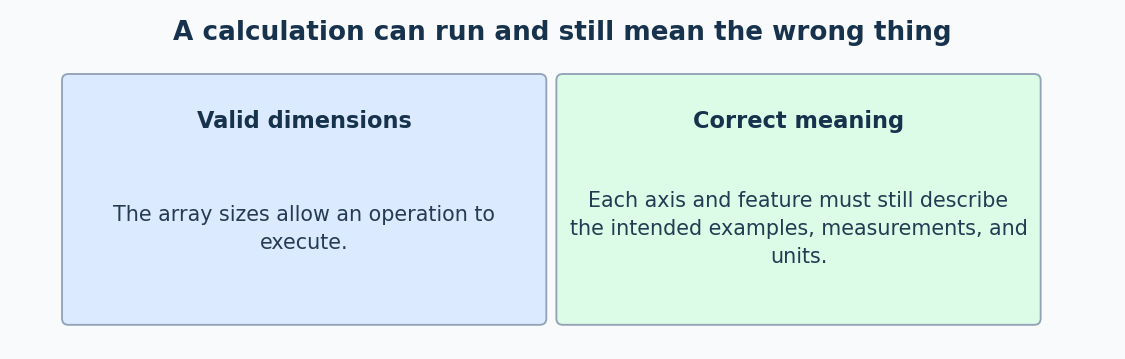

Tensor reasoning helps us connect components and explain unexpected results. But correct shapes are only part of correctness. Feature order, numerical types, devices, and the axis receiving each bias must also match the intended calculation. A successfully executed forward pass establishes what the model computed, not whether its predictions are useful in the real world.

## Turn categorical measurements into tensor columns

A categorical input such as color has no meaningful numeric distance: assigning red=0 and blue=1 would falsely imply that blue is one unit above red. **One-hot encoding** represents each known category with an indicator column. For an unknown category at inference time, an explicit policy such as an all-zero row or an “unknown” column is required.

For numeric inputs, **min-max scaling** uses training bounds to map $x$ to $(x-min)/(max-min)$. It is useful when features have different ranges, but it is sensitive to outliers and does not make a future value impossible outside $[0,1]$. Fit the transformation on training data and reuse it unchanged for validation and test data.